# Data Preparation and loose EDA

https://www.uclahealth.org/news/article/4-surprising-health-effects-noise-pollution

Searching through the data.gov, came across two data sets reported by the city of san francisco. One dataset having to do with aircraft noise exceedances as reported by SFO. The other having to do with emergency calls

evaluation of the impact of noise pollution on (emergencies / health). There is (known?) association of noise pollution on health. We cannot randomly assign / directly prescribe noise pollution. We can pseudo assign randomness by evaluating emergency calls based on noise pollution? (refer to INFO 251 example of random air pollution)

https://data.sfgov.org/Public-Safety/Fire-Department-and-Emergency-Medical-Services-Dis/nuek-vuh3/about_data

https://data.sfgov.org/Transportation/Aircraft-Noise-Exceedances/tiju-qyvs/about_data

https://data.sfgov.org/Transportation/Aircraft-Noise-Climates/qxw2-ncq3/data_preview

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date
import geopandas as gpd
import numpy as np


In [4]:
locations = pd.read_csv("location_ids.csv")
locations = locations[['location_id', 'location', 'longitude', 'latitude', 'elevation']].drop_duplicates()

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/2647970974.py:21: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  sf_map.plot(ax=ax, color='white', edgecolor='black', column='neighborhood', cmap='tab20')


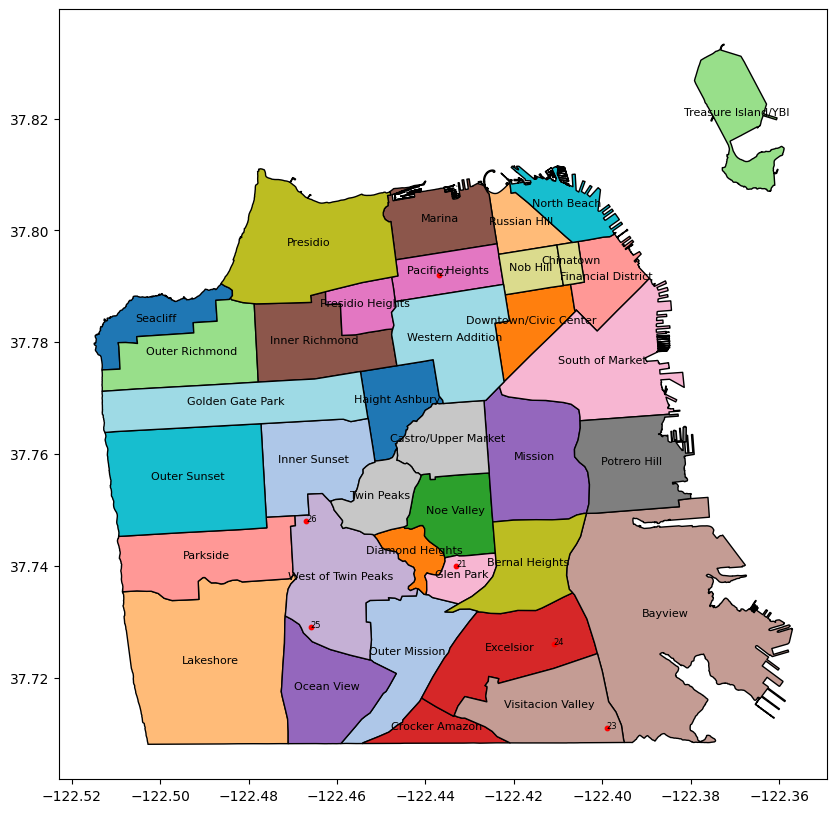

In [5]:
from shapely import wkt

# 1. Load SF Neighborhood Boundaries
sf_map = gpd.read_file('Planning_Neighborhood_Groups_Map_20260402.csv')

sf_map['geometry'] = sf_map['the_geom'].apply(wkt.loads)
sf_map = gpd.GeoDataFrame(sf_map, geometry='geometry', crs="EPSG:4326")

# 2. Create points from lon/lat
geometry = gpd.points_from_xy(locations['longitude'], locations['latitude'])

gdf = gpd.GeoDataFrame(locations, geometry=geometry, crs="EPSG:4326")

# 3. Match CRS
gdf = gdf.to_crs(sf_map.crs)

gdf_sf = gpd.clip(gdf, sf_map)

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 10))
sf_map.plot(ax=ax, color='white', edgecolor='black', column='neighborhood', cmap='tab20')
# Project for accurate centroids
sf_map_proj = sf_map.to_crs(epsg=3857)
centroids = sf_map_proj.geometry.centroid.to_crs(sf_map.crs)
# Add labels
for x, y, label in zip(centroids.x, centroids.y, sf_map['neighborho']):
    ax.text(x, y, label, fontsize=8, ha='center')
    
gdf_sf.plot(ax=ax, color='red', markersize=10)
for x, y, label in zip(gdf_sf.geometry.x, gdf_sf.geometry.y, gdf_sf['location_id']):
    ax.text(x, y, str(label), fontsize=6)

plt.show()

## Per google maps estimate, locations 25 aand 26 (both within 'West of Twin Peaks') are 2 miles away. will do 1 mile radii for location_ids

In [6]:
noise = pd.read_csv("Aircraft_Noise_Exceedances.csv")


## Remove unneccessary columns to save space for later

In [7]:
remove_noise = ['corr_id', 'operation_no', 'airline_code', 
                'other_port', 'airport_code', 'data_as_of', 
                'data_loaded_at', ]
noise = noise.drop(columns=remove_noise, axis=1)

### Add the location information to the noise df

In [8]:
noise_locations = noise.merge(locations, on='location_id', how='left')

In [9]:
noise_locations.head()


,location_id,max_date_time,classification,sel,max_level,duration,day_night,flight_date_time,operation_type,runway_name,aircraft_type,aircraft_category,airline,location,longitude,latitude,elevation
0,12,2023/03/19 11:50:49 PM,1,80.1,71.1,19,Night,2023-03-19 23:54:37,A,28R,A321,J,JETBLUE AIRWAYS,Foster City,-122.253,37.565,1.0
1,23,2023/03/20 12:01:27 AM,1,83.7,74.8,24,Night,2023-03-19 23:58:54,D,01L,B738,J,AEROMEXICO,San Francisco,-122.399,37.711,20.0
2,12,2023/03/20 12:33:18 AM,1,82.9,72.4,24,Night,2023-03-20 00:38:38,A,28R,B737,J,SOUTHWEST AIRLINES,Foster City,-122.253,37.565,1.0
3,12,2023/04/04 12:09:11 AM,1,81.5,70.3,28,Night,2023-04-04 00:14:27,A,28R,B739,J,DELTA AIR LINES,Foster City,-122.253,37.565,1.0
4,5,2023/04/04 01:29:52 AM,1,92.4,83.4,30,Night,2023-04-04 01:28:30,D,28L,B77W,J,CHINA AIRLINES,San Bruno,-122.413,37.628,25.0


In [10]:
noise_locations['clean_max_date_time'] = pd.to_datetime(noise_locations['max_date_time'], format="%Y/%m/%d %I:%M:%S %p")

In [11]:
noise_locations.head()

,location_id,max_date_time,classification,sel,max_level,duration,day_night,flight_date_time,operation_type,runway_name,aircraft_type,aircraft_category,airline,location,longitude,latitude,elevation,clean_max_date_time
0,12,2023/03/19 11:50:49 PM,1,80.1,71.1,19,Night,2023-03-19 23:54:37,A,28R,A321,J,JETBLUE AIRWAYS,Foster City,-122.253,37.565,1.0,2023-03-19 23:50:49
1,23,2023/03/20 12:01:27 AM,1,83.7,74.8,24,Night,2023-03-19 23:58:54,D,01L,B738,J,AEROMEXICO,San Francisco,-122.399,37.711,20.0,2023-03-20 00:01:27
2,12,2023/03/20 12:33:18 AM,1,82.9,72.4,24,Night,2023-03-20 00:38:38,A,28R,B737,J,SOUTHWEST AIRLINES,Foster City,-122.253,37.565,1.0,2023-03-20 00:33:18
3,12,2023/04/04 12:09:11 AM,1,81.5,70.3,28,Night,2023-04-04 00:14:27,A,28R,B739,J,DELTA AIR LINES,Foster City,-122.253,37.565,1.0,2023-04-04 00:09:11
4,5,2023/04/04 01:29:52 AM,1,92.4,83.4,30,Night,2023-04-04 01:28:30,D,28L,B77W,J,CHINA AIRLINES,San Bruno,-122.413,37.628,25.0,2023-04-04 01:29:52


In [12]:
sf_noise = noise_locations[noise_locations['location'] == 'San Francisco']

In [13]:
sf_noise['location_id'].value_counts()

location_id
23    11561
24     5129
21      919
25      700
27      300
26      167
Name: count, dtype: int64

In [14]:
# Convert to datetime if it's currently a string
sf_noise['max_date_time'] = pd.to_datetime(sf_noise['max_date_time'])


/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/3312255547.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sf_noise['max_date_time'] = pd.to_datetime(sf_noise['max_date_time'])
/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/3312255547.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sf_noise['max_date_time'] = pd.to_datetime(sf_noise['max_date_time'])


In [15]:
sf_noise['max_date'] = sf_noise['max_date_time'].dt.date
sf_noise['max_time'] = sf_noise['max_date_time'].dt.time


/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/3804642820.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sf_noise['max_date'] = sf_noise['max_date_time'].dt.date
/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/3804642820.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sf_noise['max_time'] = sf_noise['max_date_time'].dt.time


In [16]:
sf_noise['year'] = sf_noise['max_date_time'].dt.year

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/1209487206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sf_noise['year'] = sf_noise['max_date_time'].dt.year


In [17]:
sf_noise.head()

,location_id,max_date_time,classification,sel,max_level,duration,day_night,flight_date_time,operation_type,runway_name,...,aircraft_category,airline,location,longitude,latitude,elevation,clean_max_date_time,max_date,max_time,year
1,23,2023-03-20 00:01:27,1,83.7,74.8,24,Night,2023-03-19 23:58:54,D,01L,...,J,AEROMEXICO,San Francisco,-122.399,37.711,20.0,2023-03-20 00:01:27,2023-03-20,00:01:27,2023
10,23,2023-03-22 22:08:35,1,80.8,70.3,20,Night,2023-03-22 22:05:54,D,01L,...,J,DELTA AIR LINES,San Francisco,-122.399,37.711,20.0,2023-03-22 22:08:35,2023-03-22,22:08:35,2023
14,23,2023-03-24 00:22:14,1,79.8,70.2,21,Night,2023-03-24 00:19:04,D,01R,...,J,UNITED AIRLINES,San Francisco,-122.399,37.711,20.0,2023-03-24 00:22:14,2023-03-24,00:22:14,2023
40,24,2023-03-22 00:58:29,6,79.1,73.9,34,Night,2023-03-22 01:08:21,A,19L,...,J,UNITED AIRLINES,San Francisco,-122.411,37.726,165.0,2023-03-22 00:58:29,2023-03-22,00:58:29,2023
43,23,2023-03-23 22:05:53,1,82.7,72.5,25,Night,2023-03-23 22:03:09,D,01R,...,J,DELTA AIR LINES,San Francisco,-122.399,37.711,20.0,2023-03-23 22:05:53,2023-03-23,22:05:53,2023


In [18]:
one_day = sf_noise[sf_noise['max_date'] == date(2024, 12, 31)]
len(one_day)

87

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/4056143379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_day['max_time'] = one_day['max_time'].astype(str)


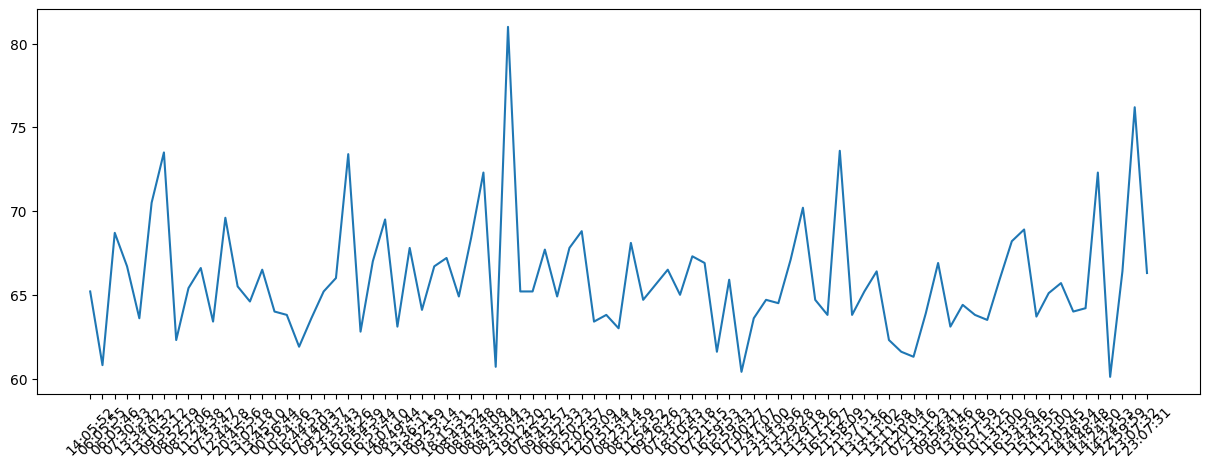

In [19]:
one_day['max_time'] = one_day['max_time'].astype(str)

plt.figure(figsize=(15, 5))
plt.plot(one_day['max_time'], one_day['max_level'])
plt.xticks(rotation=45)
plt.show()

## Maybe evaluate based on dates or even date ranges where there are a ton of flights

In [20]:
year_2023 = sf_noise[sf_noise['year']==2023]
len(year_2023)

1874

### group by time and value ; plot basic

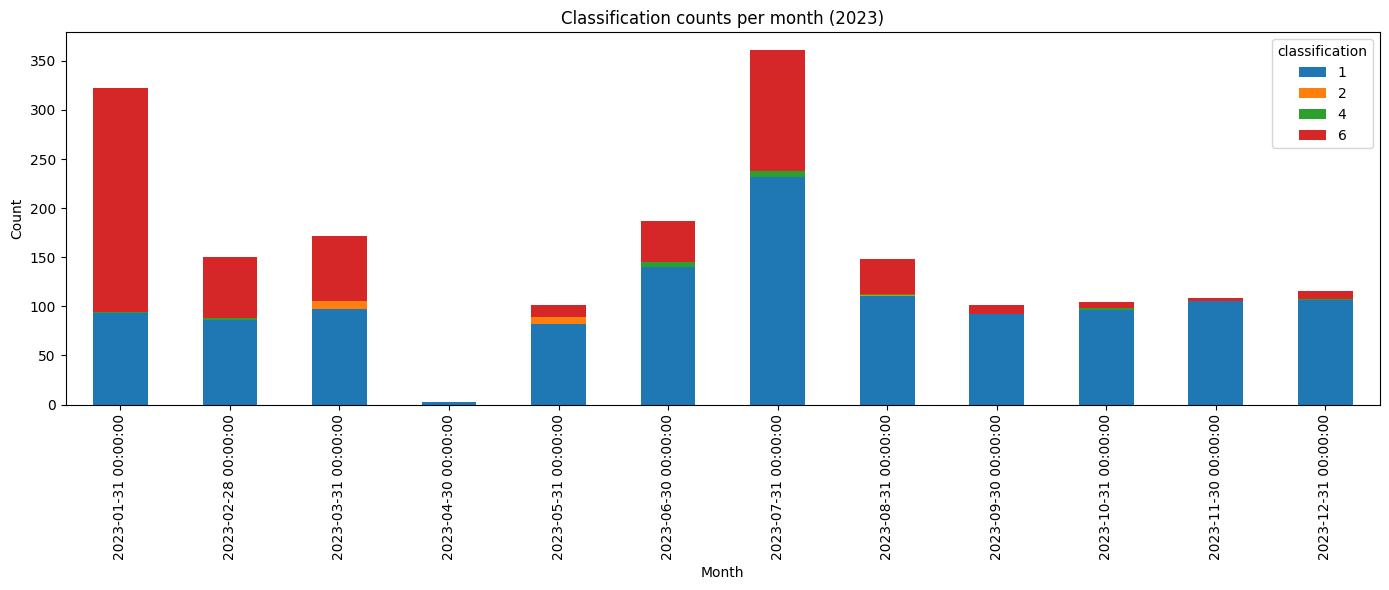

In [21]:
counts = (sf_noise[sf_noise['year'] == 2023]
            .groupby([pd.Grouper(key='clean_max_date_time', freq='ME'), 'classification'])
            .size()
            .unstack(fill_value=0))

counts.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Classification counts per month (2023)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

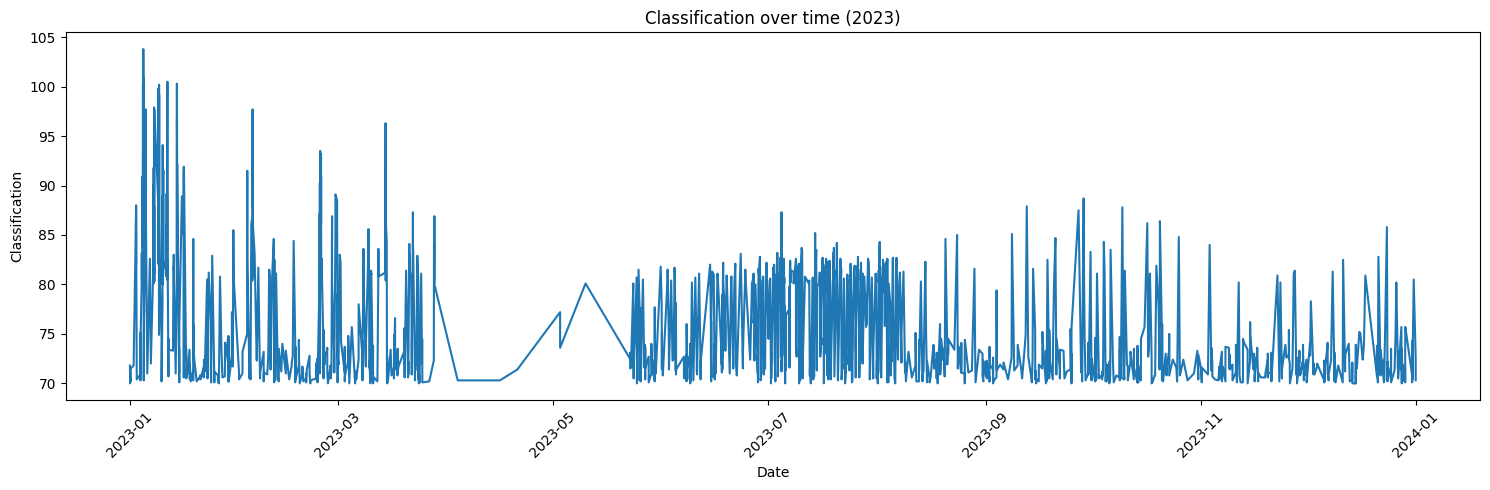

In [22]:
df_2023 = sf_noise[sf_noise['year'] == 2023].sort_values('clean_max_date_time')

plt.figure(figsize=(15, 5))
plt.plot(df_2023['clean_max_date_time'], df_2023['max_level'])
plt.xticks(rotation=45)
plt.title('Classification over time (2023)')
plt.xlabel('Date')
plt.ylabel('Classification')
plt.tight_layout()
plt.show()

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/3512630281.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


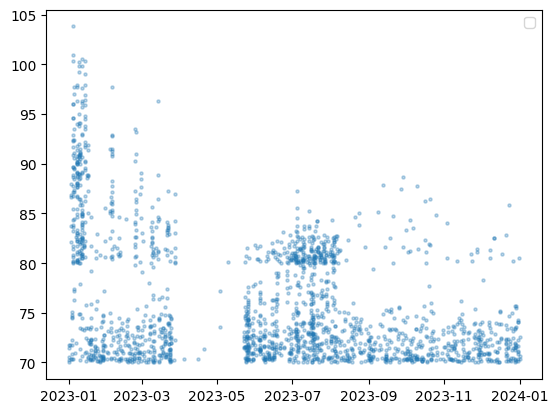

In [23]:
df_2023 = sf_noise[sf_noise['year'] == 2023].sort_values('clean_max_date_time')

# Scatter plot — better for discrete/categorical values
plt.scatter(df_2023['clean_max_date_time'], df_2023['max_level'], alpha=0.3, s=5)

plt.legend()

## Histogram; frequency of max_level occurences

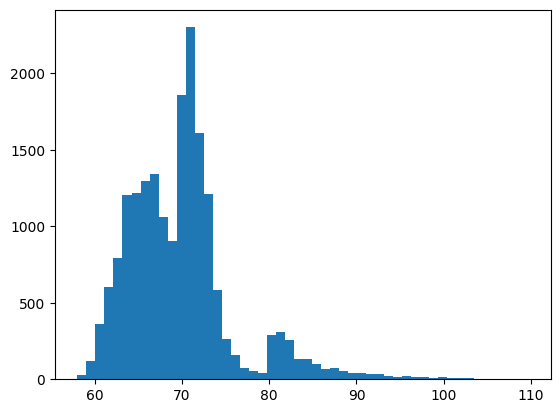

In [24]:
plt.hist(sf_noise['max_level'], bins=50)
plt.show()

https://data.sfgov.org/Transportation/Aircraft-Noise-Exceedances/tiju-qyvs/about_data

In [25]:
emergency = pd.read_csv("Fire_Department_and_Emergency_Medical_Services_Dispatched_Calls_for_Service_20260315.csv")

In [26]:
remove_emergency = [
    'Call Number', 'Unit ID', 'Incident Number', 'Entry DtTm', 
    'Dispatch DtTm', 'Response DtTm', 'On Scene DtTm', 'Transport DtTm', 
    'Hospital DtTm', 'Available DtTm', 'Battalion', 'Unit sequence in call dispatch', 
    'Fire Prevention District', 'Supervisor District', 'RowID'
]

emergency = emergency.drop(columns=remove_emergency)

In [27]:
emergency['clean_received_dtTm'] = pd.to_datetime(emergency['Received DtTm'], format="%Y %b %d %I:%M:%S %p")

In [28]:
emergency.head()

,Call Type,Call Date,Received DtTm,Call Final Disposition,Address,City,Zipcode of Incident,Station Area,Original Priority,Priority,Final Priority,ALS Unit,Call Type Group,Number of Alarms,Unit Type,Neighborhooods - Analysis Boundaries,case_location,clean_received_dtTm
0,Medical Incident,12/31/2024,2024 Dec 31 03:19:19 PM,Other,CALL BOX: TAYLOR ST/EDDY ST,San Francisco,94102.0,3.0,2,2,2,False,Non Life-threatening,1,BLS,Tenderloin,POINT (-122.411015164 37.78418755),2024-12-31 15:19:19
1,Other,12/31/2024,2024 Dec 31 01:36:29 AM,Other,FRANKLIN ST/HICKORY ST,San Francisco,94102.0,36.0,B,3,3,True,Alarm,1,ENGINE,Hayes Valley,POINT (-122.42105326 37.775695233),2024-12-31 01:36:29
2,Other,12/31/2024,2024 Dec 31 01:36:29 AM,Other,FRANKLIN ST/HICKORY ST,San Francisco,94102.0,36.0,B,3,3,False,Alarm,1,CHIEF,Hayes Valley,POINT (-122.42105326 37.775695233),2024-12-31 01:36:29
3,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,Code 2 Transport,POST ST/STEINER ST,San Francisco,94115.0,5.0,3,3,3,True,Potentially Life-Threatening,1,ENGINE,Japantown,POINT (-122.434729992 37.784944006),2024-12-31 03:17:09
4,Medical Incident,12/31/2024,2024 Dec 31 02:06:51 AM,Code 2 Transport,INNES CT/KENNEDY PL,Hunters Point,94124.0,17.0,3,3,3,True,Potentially Life-Threatening,1,MEDIC,Bayview Hunters Point,POINT (-122.367922359 37.727398351),2024-12-31 02:06:51


In [29]:
med_inc = emergency[emergency['Call Type']=='Medical Incident']

In [30]:
med_inc.columns

Index(['Call Type', 'Call Date', 'Received DtTm', 'Call Final Disposition',
       'Address', 'City', 'Zipcode of Incident', 'Station Area',
       'Original Priority', 'Priority', 'Final Priority', 'ALS Unit',
       'Call Type Group', 'Number of Alarms', 'Unit Type',
       'Neighborhooods - Analysis Boundaries', 'case_location',
       'clean_received_dtTm'],
      dtype='object')

In [31]:
med_inc['Call Type Group'].value_counts()

Call Type Group
Potentially Life-Threatening    172751
Non Life-threatening             67836
Alarm                              319
Fire                                 2
Name: count, dtype: int64

In [32]:
med_inc.drop(med_inc[med_inc['Call Type Group'] == 'Fire'].index, inplace=True)
med_inc.drop(med_inc[med_inc['Call Type Group'] == 'Alarm'].index, inplace=True)


/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/634451240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  med_inc.drop(med_inc[med_inc['Call Type Group'] == 'Fire'].index, inplace=True)
/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/634451240.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  med_inc.drop(med_inc[med_inc['Call Type Group'] == 'Alarm'].index, inplace=True)


In [33]:
med_inc['Call Type Group'].value_counts()

Call Type Group
Potentially Life-Threatening    172751
Non Life-threatening             67836
Name: count, dtype: int64

In [34]:
med_inc['case_location']

0          POINT (-122.411015164 37.78418755)
3         POINT (-122.434729992 37.784944006)
4         POINT (-122.367922359 37.727398351)
9         POINT (-122.427913715 37.776253668)
10        POINT (-122.439640305 37.716958531)
                         ...                 
368893    POINT (-122.435187962 37.762670707)
368894    POINT (-122.410401493 37.778785373)
368895    POINT (-122.405847485 37.775231052)
368897    POINT (-122.393263731 37.794229821)
368899    POINT (-122.469667022 37.738505273)
Name: case_location, Length: 240996, dtype: object

In [35]:
# Assuming 'df' is your dataframe and 'case_location' is the column name
# This regex looks for two numbers (including decimals and signs) inside the parentheses
coords = med_inc['case_location'].str.extract(r'POINT \((?P<longitude>-?\d+\.\d+) (?P<latitude>-?\d+\.\d+)\)')

# Convert the extracted strings to floats
med_inc['longitude'] = coords['longitude'].astype(float)
med_inc['latitude'] = coords['latitude'].astype(float)



/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/999035746.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  med_inc['longitude'] = coords['longitude'].astype(float)
/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/999035746.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  med_inc['latitude'] = coords['latitude'].astype(float)


## Need some sort of function to take longitude and lat of call and associate with a location_id
Give location_id a radius and see if long/lat of medical occurrence falls within that radius

**Above I decided 1 mile radii** as default, can play around later as a stability test

In [36]:
def assign_location_id(point_lat, point_lon, ref_df, radius_miles=1.0):
    """
    Finds the first location_id within the specified mile radius.
    Returns np.nan if no match is found.
    """
    # Earth's radius in miles
    R = 3958.8
    
    # Convert degrees to radians for calculations
    ref_lats = np.radians(ref_df['latitude'])
    ref_lons = np.radians(ref_df['longitude'])
    p_lat = np.radians(point_lat)
    p_lon = np.radians(point_lon)
    
    # Haversine formula
    dlat = ref_lats - p_lat
    dlon = ref_lons - p_lon
    
    a = np.sin(dlat/2)**2 + np.cos(p_lat) * np.cos(ref_lats) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    
    # Filter for locations within radius
    within_radius = ref_df[distance <= radius_miles]
    
    if not within_radius.empty:
        return within_radius.iloc[0]['location_id']
    return np.nan

# Example Usage:
# df_points['location_id'] = df_points.apply(
#     lambda row: assign_location_id(row['lat'], row['lon'], df_locations), axis=1
# )

In [37]:
med_inc['location_id'] = med_inc.apply(
     lambda row: assign_location_id(row['latitude'], row['longitude'], locations), axis=1)

/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_9694/1873987509.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  med_inc['location_id'] = med_inc.apply(


In [38]:
print(f"Medical instances associated with location_id: {med_inc['location_id'].notna().sum()}")

Medical instances associated with location_id: 55500


In [39]:
med_inc['location_id'].value_counts()

location_id
27.0    21730
21.0     7415
24.0     6248
26.0     5633
20.0     5039
25.0     4887
23.0     4548
Name: count, dtype: int64

Nice! still plenty of data

Drop nan and turn into integer

In [40]:
med_inc = med_inc.dropna(subset=['location_id'])
med_inc['location_id'] = med_inc['location_id'].astype(int)

<Axes: xlabel='location_id'>

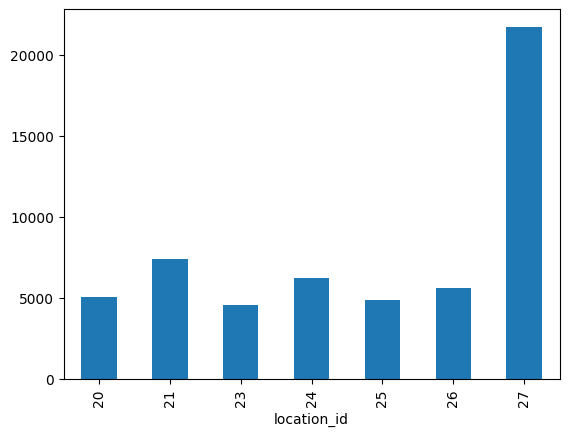

In [41]:
med_inc.groupby('location_id').size().plot(kind='bar')

In [42]:
med_inc.head()

,Call Type,Call Date,Received DtTm,Call Final Disposition,Address,City,Zipcode of Incident,Station Area,Original Priority,Priority,...,ALS Unit,Call Type Group,Number of Alarms,Unit Type,Neighborhooods - Analysis Boundaries,case_location,clean_received_dtTm,longitude,latitude,location_id
3,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,Code 2 Transport,POST ST/STEINER ST,San Francisco,94115.0,5.0,3,3,...,True,Potentially Life-Threatening,1,ENGINE,Japantown,POINT (-122.434729992 37.784944006),2024-12-31 03:17:09,-122.434730,37.784944,27
10,Medical Incident,12/31/2024,2024 Dec 31 02:58:32 AM,Other,AMAZON AVE/LONDON ST,San Francisco,94112.0,43.0,A,2,...,True,Potentially Life-Threatening,1,MEDIC,Excelsior,POINT (-122.439640305 37.716958531),2024-12-31 02:58:32,-122.439640,37.716959,20
12,Medical Incident,12/31/2024,2024 Dec 31 01:51:18 AM,Code 2 Transport,HALE ST/MERRILL ST,San Francisco,94134.0,42.0,2,2,...,True,Potentially Life-Threatening,1,MEDIC,Portola,POINT (-122.409172384 37.731963964),2024-12-31 01:51:18,-122.409172,37.731964,24
15,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,Code 2 Transport,POST ST/STEINER ST,San Francisco,94115.0,5.0,3,3,...,True,Potentially Life-Threatening,1,MEDIC,Japantown,POINT (-122.434729992 37.784944006),2024-12-31 03:17:09,-122.434730,37.784944,27
52,Medical Incident,12/31/2024,2024 Dec 31 03:36:52 PM,Code 2 Transport,FRANKLIN ST/JACKSON ST,San Francisco,94109.0,38.0,A,2,...,True,Non Life-threatening,1,MEDIC,Pacific Heights,POINT (-122.424694144 37.793726022),2024-12-31 15:36:52,-122.424694,37.793726,27


## Now I need to somehow combine the two datasets. 
Maybe first look for medical occurrences 1 hour after max time in noise occurrence

In [43]:
med_inc['Received DtTm'] = pd.to_datetime(med_inc['Received DtTm'], format='%Y %b %d %I:%M:%S %p')


In [44]:
'''Taking long asf

merged_df = pd.merge(
    med_inc, 
    sf_noise, 
    on='location_id', 
    suffixes=('_call', '_noise')
)
'''

"Taking long asf\n\nmerged_df = pd.merge(\n    med_inc, \n    sf_noise, \n    on='location_id', \n    suffixes=('_call', '_noise')\n)\n"

In [45]:
med_inc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55500 entries, 3 to 368899
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Call Type                             55500 non-null  object        
 1   Call Date                             55500 non-null  object        
 2   Received DtTm                         55500 non-null  datetime64[ns]
 3   Call Final Disposition                55500 non-null  object        
 4   Address                               55500 non-null  object        
 5   City                                  55464 non-null  object        
 6   Zipcode of Incident                   55443 non-null  float64       
 7   Station Area                          55500 non-null  float64       
 8   Original Priority                     54712 non-null  object        
 9   Priority                              55500 non-null  object        
 10  Fi

In [46]:
sf_noise.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18776 entries, 1 to 242278
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   location_id          18776 non-null  int64         
 1   max_date_time        18776 non-null  datetime64[ns]
 2   classification       18776 non-null  int64         
 3   sel                  18776 non-null  float64       
 4   max_level            18776 non-null  float64       
 5   duration             18776 non-null  int64         
 6   day_night            18776 non-null  object        
 7   flight_date_time     18654 non-null  object        
 8   operation_type       18654 non-null  object        
 9   runway_name          18649 non-null  object        
 10  aircraft_type        18653 non-null  object        
 11  aircraft_category    18412 non-null  object        
 12  airline              18366 non-null  object        
 13  location             18776 non-null

In [47]:
med_inc['location_id'].value_counts()

location_id
27    21730
21     7415
24     6248
26     5633
20     5039
25     4887
23     4548
Name: count, dtype: int64

In [48]:
sf_noise['location_id'].value_counts()

location_id
23    11561
24     5129
21      919
25      700
27      300
26      167
Name: count, dtype: int64

## Test location_id 25 first

In [49]:
med_inc_25 = med_inc[med_inc['location_id']==25]
print(len(med_inc_25))
sf_noise_25 = sf_noise[sf_noise['location_id']==25]
print(len(sf_noise_25))

4887
700


In [50]:
merged = pd.merge(
    med_inc_25, 
    sf_noise_25, 
    on='location_id', 
    suffixes=('_med', '_noise')
)

# 3. Calculate the absolute time difference
merged['time_diff'] = (merged['Received DtTm'] - merged['max_date_time']).abs()

# 4. Filter for occurrences within 1 hour (3600 seconds)
# We use .total_seconds() or a Timedelta comparison
matches = merged[merged['time_diff'] <= pd.Timedelta(hours=1)]

# 5. Count the results
count = len(matches)

print(f"Number of medical occurrences within 1 hour of a noise incident: {count}")

Number of medical occurrences within 1 hour of a noise incident: 9


In [51]:
def count_matches_efficient(df_med, df_noise, window_hours=1):
    # 1. Sort both by time (REQUIRED for merge_asof)
    df_med = df_med.sort_values('Received DtTm')
    df_noise = df_noise.sort_values('max_date_time')
    
    # 2. Perform the 'asof' merge
    # This matches each med call to the NEAREST noise event within the tolerance
    # 'by' ensures we only match within the same location_id
    matches = pd.merge_asof(
        df_med, 
        df_noise, 
        left_on='Received DtTm', 
        right_on='max_date_time', 
        by='location_id', 
        direction='nearest',
        tolerance=pd.Timedelta(hours=window_hours)
    )
    
    # 3. Drop rows that didn't find a match within the 1-hour window
    # (These will have NaN in the noise columns)
    valid_matches = matches.dropna(subset=['max_date_time'])
    
    # 4. Group by location to get counts
    counts = valid_matches.groupby('location_id').size().reset_index(name='match_count')
    
    return counts

# Run on your full 2023 data
final_counts = count_matches_efficient(med_inc, sf_noise)
print(final_counts)

   location_id  match_count
0           21           43
1           23          569
2           24           99
3           25            7
4           26            4
5           27           45
